# Exercise 1 - Improving REINFORCE on CartPole

This notebook covers the first part of the Deep Reinforcement Learning laboratory.

Goal: start from the professor's REINFORCE idea, refactor the code into reusable functions, and add a better evaluation protocol.

We use `CartPole-v1` because it has continuous observations and a small discrete action space. The official Gymnasium specification says that the observation has shape `(4,)`, the action space is `Discrete(2)`, and the default reward threshold for `CartPole-v1` is 500.

AI disclosure: ChatGPT/Codex was used to help reorganize the lab into clean notebooks and reusable helper functions. The code and results must be rerun and checked manually before submission.

> **Execution note**
>
> Gli output visibili sono stati prodotti durante le esecuzioni finali o di validazione del laboratorio. Nella versione di consegna i training costosi sono disattivati di default quando sono controllati da flag; checkpoint e artefatti salvati vengono usati per consultazione rapida.

## Setup

The notebook stays short. The implementation lives in `src/dla_lab3`.

This is intentional: functions can be inspected, tested and reused without copying long code blocks across notebooks.

In [1]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

PROJECT_ROOT

PosixPath('DLA_3')

In [2]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from dla_lab3 import (
    ReinforceConfig,
    evaluate_policy,
    make_env,
    observation_scale,
    reinforce,
    run_episode,
    set_seed,
)
from dla_lab3.paths import checkpoint_dir
from dla_lab3.plotting import plot_evaluation, plot_training_returns
from dla_lab3.policy_gradient import policy_from_env

# Sweep, training e rendering sono opt-in nella consegna.
RUN_GAMMA_SWEEP = False
RUN_REINFORCE_TRAINING = False
RUN_VISUAL_EVALUATION = False


## References and Methodological Choices

This notebook is based on three sources:

- the professor's `reinforce-cartpole` repository, used as the reference implementation of REINFORCE;
- the exploratory notebook `DLA_3/Lab3.ipynb`, used to preserve the successful choices already tested locally (`gamma=0.98`, periodic greedy evaluation, checkpointing);
- the official Gymnasium documentation for `CartPole-v1`, used for the observation space, action space, reward structure and episode limit.

The implementation follows these choices:

- the algorithm is kept in `src/dla_lab3` instead of being copied into the notebook;
- the training policy samples actions from a categorical distribution;
- the evaluation policy is greedy, so the reported metrics measure the learned policy rather than exploration noise;
- the reported performance is based on average total reward and average episode length over multiple evaluation episodes.

## 1. Understand the Environment

First we inspect the environment manually, as requested by the exercise.

Important facts:

- observation 0: cart position;
- observation 1: cart velocity;
- observation 2: pole angle;
- observation 3: pole angular velocity;
- action 0: push left;
- action 1: push right.

In [3]:
SEED = 2112
set_seed(SEED)

env = make_env("CartPole-v1", seed=SEED)
obs, info = env.reset(seed=SEED)

print("Initial observation:", obs)
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)
print("Observation low:", env.observation_space.low)
print("Observation high:", env.observation_space.high)

for step in range(5):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    print(
        f"step={step + 1} action={action} reward={reward} "
        f"terminated={terminated} truncated={truncated}"
    )
    if terminated or truncated:
        obs, info = env.reset()

env.close()

Initial observation: [-0.04156577  0.03325528 -0.04219181  0.01717232]
Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action space: Discrete(2)
Observation low: [-4.8               -inf -0.41887903        -inf]
Observation high: [4.8               inf 0.41887903        inf]
step=1 action=0 reward=1.0 terminated=False truncated=False
step=2 action=0 reward=1.0 terminated=False truncated=False
step=3 action=1 reward=1.0 terminated=False truncated=False
step=4 action=1 reward=1.0 terminated=False truncated=False
step=5 action=1 reward=1.0 terminated=False truncated=False


Observation: the environment gives reward `+1` at every step. For CartPole, a higher total reward usually means that the pole stayed balanced for more timesteps.

## 2. Check an Untrained Policy

Before training, we instantiate the policy network and evaluate it. The network is untrained, so this gives a weak baseline for comparison.

We evaluate both action-selection modes:

- `sample`: stochastic policy, useful to understand exploration;
- `greedy`: deterministic policy, same mode used for periodic evaluation during training.

In [4]:
set_seed(SEED)
env = make_env("CartPole-v1", seed=SEED)
obs_scale = observation_scale("CartPole-v1")

policy = policy_from_env(env, hidden_size=128)
print(policy)

untrained_stochastic_eval = evaluate_policy(
    env,
    policy,
    obs_scale,
    episodes=20,
    mode="sample",
    seed_start=10_000,
)

untrained_greedy_eval = evaluate_policy(
    env,
    policy,
    obs_scale,
    episodes=20,
    mode="greedy",
    seed_start=11_000,
)

{
    "stochastic_untrained": untrained_stochastic_eval,
    "greedy_untrained": untrained_greedy_eval,
}

PolicyNet(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=2, bias=True)
  )
)


{'stochastic_untrained': {'avg_return': 22.75,
  'std_return': 10.549288749694824,
  'min_return': 9.0,
  'max_return': 50.0,
  'avg_length': 22.75,
  'returns': [16.0,
   9.0,
   17.0,
   30.0,
   13.0,
   27.0,
   23.0,
   44.0,
   15.0,
   12.0,
   38.0,
   28.0,
   50.0,
   19.0,
   26.0,
   17.0,
   19.0,
   18.0,
   16.0,
   18.0],
  'lengths': [16,
   9,
   17,
   30,
   13,
   27,
   23,
   44,
   15,
   12,
   38,
   28,
   50,
   19,
   26,
   17,
   19,
   18,
   16,
   18]},
 'greedy_untrained': {'avg_return': 9.149999618530273,
  'std_return': 0.6538348197937012,
  'min_return': 8.0,
  'max_return': 10.0,
  'avg_length': 9.149999618530273,
  'returns': [10.0,
   9.0,
   9.0,
   9.0,
   8.0,
   10.0,
   10.0,
   10.0,
   9.0,
   9.0,
   9.0,
   9.0,
   10.0,
   10.0,
   9.0,
   9.0,
   9.0,
   8.0,
   9.0,
   8.0],
  'lengths': [10,
   9,
   9,
   9,
   8,
   10,
   10,
   10,
   9,
   9,
   9,
   9,
   10,
   10,
   9,
   9,
   9,
   8,
   9,
   8]}}

## 3. Discount Factor Sensitivity

The professor explicitly suggests checking the effect of the discount factor `gamma`. This is important because the running reward depends on `gamma`, and because REINFORCE can be unstable.

Here I run a small controlled sweep on CartPole before the final training run. The comparison keeps the same seed, network size, optimizer, evaluation protocol and standardization baseline. Only `gamma` changes.

To keep the notebook practical, the sweep uses fewer training episodes than the final run. The selected value is then reused in the main training cell below.

In [ ]:
if RUN_GAMMA_SWEEP:
    GAMMA_VALUES = [0.95, 0.98, 0.99]
    GAMMA_SWEEP_EPISODES = 500
    GAMMA_SWEEP_EVAL_EVERY = 50
    GAMMA_SWEEP_EVAL_EPISODES = 10


    def first_episode_reaching(history, threshold=500.0):
        for episode, avg_return in zip(history["eval_episodes"], history["eval_avg_returns"]):
            if avg_return >= threshold:
                return episode
        return None


    def run_gamma_experiment(gamma, seed=SEED):
        set_seed(seed)
        train_env = make_env("CartPole-v1", seed=seed)
        eval_env = make_env("CartPole-v1", seed=seed + 1000)
        obs_scale = observation_scale("CartPole-v1")

        policy_gamma = policy_from_env(train_env, hidden_size=128)
        gamma_tag = str(gamma).replace(".", "")

        config_gamma = ReinforceConfig(
            gamma=gamma,
            lr_policy=3e-4,
            num_episodes=GAMMA_SWEEP_EPISODES,
            eval_every=GAMMA_SWEEP_EVAL_EVERY,
            eval_episodes=GAMMA_SWEEP_EVAL_EPISODES,
            baseline_mode="standardize",
            entropy_coef=0.01,
            checkpoint_path=str(checkpoint_dir("gamma_sweep", f"cartpole_reinforce_gamma_{gamma_tag}.pt")),
        )

        history_gamma = reinforce(policy_gamma, train_env, eval_env, obs_scale, config_gamma)
        train_env.close()
        eval_env.close()

        return history_gamma


    gamma_histories = {}
    gamma_results = []

    for gamma in GAMMA_VALUES:
        history_gamma = run_gamma_experiment(gamma)
        gamma_histories[gamma] = history_gamma
        gamma_results.append(
            {
                "gamma": gamma,
                "best_eval_return": max(history_gamma["eval_avg_returns"]),
                "final_eval_return": history_gamma["eval_avg_returns"][-1],
                "first_episode_reaching_500": first_episode_reaching(history_gamma),
            }
        )

    gamma_results
else:
    gamma_histories = {}
    gamma_results = []
    SELECTED_GAMMA = 0.98
    print("Gamma sweep non eseguito; configurazione finale gamma=0.98.")


In [ ]:
if RUN_GAMMA_SWEEP:
    plt.figure(figsize=(10, 4))

    for gamma, history_gamma in gamma_histories.items():
        plt.plot(
            history_gamma["eval_episodes"],
            history_gamma["eval_avg_returns"],
            marker="o",
            label=f"gamma={gamma}",
        )

    plt.axhline(500, linestyle="--", color="tab:green", label="CartPole threshold")
    plt.xlabel("Training episode")
    plt.ylabel("Average greedy evaluation return")
    plt.title("CartPole-v1 - discount factor comparison")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    best_gamma_row = max(
        gamma_results,
        key=lambda row: (row["best_eval_return"], row["final_eval_return"]),
    )
    SELECTED_GAMMA = best_gamma_row["gamma"]

    best_gamma_row
else:
    print("Grafico gamma sweep disponibile nell'output eseguito.")


The selected `gamma` is the one with the highest best evaluation return. If two values obtain the same best return, the final evaluation return is used as a tie-breaker. This keeps the choice explicit and reproducible.

## 4. Train REINFORCE with Periodic Evaluation

The professor's original implementation tracks a running reward during training. That is useful but not enough.

Here we add the requested evaluation:

- every `N = eval_every` training episodes;
- run the agent for `M = eval_episodes` evaluation episodes;
- collect average total reward;
- collect average episode length.

Training uses stochastic actions because REINFORCE needs exploration. Evaluation uses greedy actions to measure the policy learned by the network.

In [5]:
if RUN_REINFORCE_TRAINING:
    set_seed(SEED)
    train_env = make_env("CartPole-v1", seed=SEED)
    eval_env = make_env("CartPole-v1", seed=SEED + 1000)
    obs_scale = observation_scale("CartPole-v1")

    policy = policy_from_env(train_env, hidden_size=128)

    try:
        selected_gamma = SELECTED_GAMMA
    except NameError:
        selected_gamma = 0.98

    config = ReinforceConfig(
        gamma=selected_gamma,
        lr_policy=3e-4,
        num_episodes=1000,
        eval_every=50,
        eval_episodes=20,
        baseline_mode="standardize",
        entropy_coef=0.01,
        checkpoint_path=str(checkpoint_dir("cartpole_reinforce_standardized.pt")),
    )

    history = reinforce(policy, train_env, eval_env, obs_scale, config)

    train_env.close()
    eval_env.close()
else:
    history = None
    print("Training REINFORCE non eseguito in modalita' rapida.")


episode=    0 train_return=   16.00 eval_return=    9.25 eval_length=    9.2
episode=   50 train_return=   21.00 eval_return=  116.45 eval_length=  116.4
episode=  100 train_return=   46.00 eval_return=  295.40 eval_length=  295.4
episode=  150 train_return=   39.00 eval_return=   72.95 eval_length=   72.9
episode=  200 train_return=   21.00 eval_return=  160.90 eval_length=  160.9
episode=  250 train_return=   19.00 eval_return=  489.35 eval_length=  489.4
episode=  300 train_return=   51.00 eval_return=  179.25 eval_length=  179.2
episode=  350 train_return=  144.00 eval_return=  210.40 eval_length=  210.4
episode=  400 train_return=   98.00 eval_return=  373.45 eval_length=  373.5
episode=  450 train_return=   82.00 eval_return=  269.45 eval_length=  269.5
episode=  500 train_return=  315.00 eval_return=  441.70 eval_length=  441.7
episode=  550 train_return=  152.00 eval_return=  185.00 eval_length=  185.0
episode=  600 train_return=  122.00 eval_return=  193.45 eval_length=  193.4

Implementation notes for reproducibility:

- `eval_every=50` is the requested `N`;
- `eval_episodes=20` is the requested `M`;
- the training policy samples actions from a categorical distribution;
- periodic evaluation uses greedy actions and `torch.no_grad()`;
- a separate `eval_env` avoids mixing training rollouts and evaluation rollouts;
- the best model is saved in the local `checkpoints/` folder connected to this lab.

The printed training lines are not the final evaluation. They are progress logs. The final interpretation should use the plots and the summary table below.

## 5. Analyze Training and Evaluation

The raw episode return is noisy because each trajectory is sampled from a stochastic policy. The periodic evaluation curve is more reliable because it averages multiple episodes.

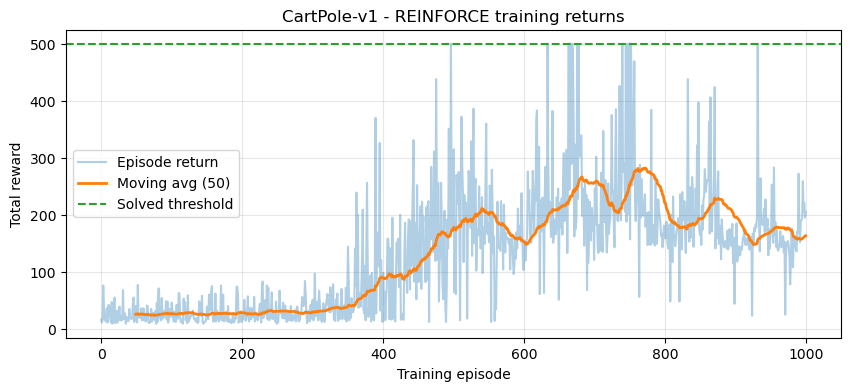

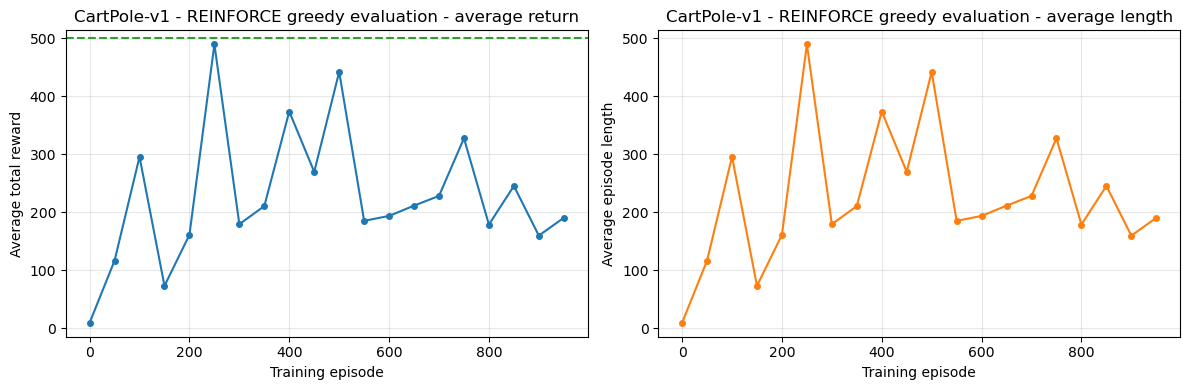

In [6]:
if history is not None:
    plot_training_returns(
        history,
        title="CartPole-v1 - REINFORCE training returns",
        solved_threshold=500,
        window=50,
    )
    plot_evaluation(
        history,
        title="CartPole-v1 - REINFORCE greedy evaluation",
        solved_threshold=500,
    )
else:
    print("Curve preservate nell'output e in figures/.")


In [7]:
if history is not None:
    summary = [
        {"metric": "best_eval_return", "value": history["best_eval_return"]},
        {"metric": "final_eval_return", "value": history["eval_avg_returns"][-1]},
        {"metric": "final_eval_length", "value": history["eval_avg_lengths"][-1]},
        {"metric": "checkpoint_path", "value": history["checkpoint_path"]},
    ]
    summary
else:
    display(pd.read_csv(PROJECT_ROOT / "results" / "method_summary.csv").query("method == 'REINFORCE standardized returns'"))


[{'metric': 'best_eval_return', 'value': 489.3500061035156},
 {'metric': 'final_eval_return', 'value': 190.1999969482422},
 {'metric': 'final_eval_length', 'value': 190.1999969482422},
 {'metric': 'checkpoint_path',
  'value': 'DLA_3/checkpoints/cartpole_reinforce_standardized.pt'}]

## 6. Qualitative Visual Check

La visualizzazione CartPole e' consolidata nel notebook
[`02_cartpole_value_baseline.ipynb`](02_cartpole_value_baseline.ipynb), perche'
usa il checkpoint della configurazione value-baseline selezionata. In questo modo
non esistono implementazioni duplicate o controlli visuali basati su un modello
meno forte.

## Conclusions

This notebook completes Exercise 1 in the following way:

- the CartPole environment is inspected before training;
- the REINFORCE implementation is imported from reusable code in `src/dla_lab3`;
- training and evaluation are separated;
- a small discount-factor sweep compares `gamma = 0.95`, `0.98` and `0.99`;
- the selected `gamma` is reused in the final REINFORCE training run;
- the evaluation protocol runs every `N = 50` training episodes and uses `M = 20` episodes;
- the returned metrics include average total reward and average episode length, as requested.

Final interpretation after rerun:

- If the average evaluation return reaches 500, the learned policy solves `CartPole-v1`.
- If the return remains below 500, the result should be discussed as a limitation of vanilla REINFORCE: high variance, sensitivity to the seed, sensitivity to the learning rate and limited stabilization from the simple standardization baseline.

Compared with the exploratory notebook, this final version removes duplicated code, avoids hard-coded local paths, saves checkpoints inside the lab folder and documents the inputs and outputs of the reusable functions.

## Referenced functions and source files

| Function/class | Defined in | Purpose |
| --- | --- | --- |
| `reinforce` / `reinforce_with_value_baseline` | `src/dla_lab3/policy_gradient.py` | Training policy-gradient su CartPole. |
| `A2CConfig` / `train_a2c_vectorized` | `src/dla_lab3/a2c.py` | Configurazione e training A2C. |
| `evaluate_lunar_candidates` | `src/dla_lab3/experiments.py` | Valutazione checkpoint LunarLander. |
| `run_lunar_visual_episodes` | `src/dla_lab3/visualization.py` | Rollout visuali finali. |
